In [1]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [2]:
import yfinance as yf

test = yf.download('AAPL', start='2020-01-01', end='2024-01-01', progress=False)['Close']
print(f"Data points: {len(test)}")
print(test.tail())

Data points: 1006
Ticker            AAPL
Date                  
2023-12-22  191.609467
2023-12-26  191.065125
2023-12-27  191.164108
2023-12-28  191.589691
2023-12-29  190.550461


In [8]:
import yfinance as yf
import time

stocks_to_test = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']

working = []
for ticker in stocks_to_test:
    time.sleep(2)
    test = yf.download(ticker, start='2019-01-01', end='2024-01-01', progress=False)['Close']
    if len(test) > 100:
        print(f" {ticker} — {len(test)} data points")
        working.append(ticker)
    else:
        print(f" {ticker} — failed")

print(f"\n Working tickers: {working}")

 AAPL — 1258 data points
 MSFT — 1258 data points
 GOOGL — 1258 data points
 AMZN — 1258 data points
 TSLA — 1258 data points

 Working tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']


In [9]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

print(" Libraries loaded successfully")

 Libraries loaded successfully


In [10]:
stocks = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']

stock_names = {
    'AAPL': 'Apple',
    'MSFT': 'Microsoft',
    'GOOGL': 'Google',
    'AMZN': 'Amazon',
    'TSLA': 'Tesla'
}
print(f" Downloading data for: {stocks}")

data = yf.download(stocks, start='2019-01-01', end='2024-01-01', progress=False)['Close']


data = data.dropna()

print(f" Downloaded {len(data)} days of data")
data.tail()


 Downloaded 1258 days of data


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2023-12-22,191.609467,153.419998,140.330154,368.236603,252.539993
2023-12-26,191.065094,153.410004,140.359940,368.315277,256.609985
2023-12-27,191.164078,153.339996,139.219360,367.735229,261.440002
2023-12-28,191.589676,153.380005,139.080521,368.924774,253.179993
2023-12-29,190.550491,151.940002,138.544922,369.671875,248.479996


In [11]:
returns = data.pct_change().dropna()

print("📊 Average Daily Returns:")
print(returns.mean())

print("\n📉 Daily Volatility (Risk):")
print(returns.std())

returns.tail()

📊 Average Daily Returns:
Ticker
AAPL     0.001500
AMZN     0.000787
GOOGL    0.000976
MSFT     0.001271
TSLA     0.002810
dtype: float64

📉 Daily Volatility (Risk):
Ticker
AAPL     0.020306
AMZN     0.022187
GOOGL    0.020038
MSFT     0.019207
TSLA     0.040757
dtype: float64


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2023-12-22,-0.005547,-0.002730,0.007620,0.002784,-0.007701
2023-12-26,-0.002841,-0.000065,0.000212,0.000214,0.016116
2023-12-27,0.000518,-0.000456,-0.008126,-0.001575,0.018822
2023-12-28,0.002226,0.000261,-0.000997,0.003235,-0.031594
2023-12-29,-0.005424,-0.009388,-0.003851,0.002025,-0.018564


In [12]:

trading_days = 252


mean_returns = returns.mean() * trading_days


cov_matrix = returns.cov() * trading_days

print(" Annualized Expected Returns:")
for stock, ret in mean_returns.items():
    print(f"  {stock_names.get(stock, stock)}: {ret:.1%}")

print("\n How correlated are these stocks? (1 = move together, 0 = independent)")
print(returns.corr().round(2))

 Annualized Expected Returns:
  Apple: 37.8%
  Amazon: 19.8%
  Google: 24.6%
  Microsoft: 32.0%
  Tesla: 70.8%

 How correlated are these stocks? (1 = move together, 0 = independent)
Ticker  AAPL  AMZN  GOOGL  MSFT  TSLA
Ticker                               
AAPL    1.00  0.62   0.67  0.76  0.49
AMZN    0.62  1.00   0.66  0.68  0.44
GOOGL   0.67  0.66   1.00  0.76  0.41
MSFT    0.76  0.68   0.76  1.00  0.45
TSLA    0.49  0.44   0.41  0.45  1.00


In [13]:
num_portfolios = 10000
num_stocks = len(stocks)


portfolio_returns = np.zeros(num_portfolios)
portfolio_volatility = np.zeros(num_portfolios)
portfolio_sharpe = np.zeros(num_portfolios)
portfolio_weights = np.zeros((num_portfolios, num_stocks))


risk_free_rate = 0.03

print(" Running 10,000 simulations...")

for i in range(num_portfolios):
    weights = np.random.random(num_stocks)
    weights = weights / np.sum(weights)
    portfolio_weights[i] = weights
    
    
    port_return = np.sum(mean_returns * weights)
    portfolio_returns[i] = port_return
    
    
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    portfolio_volatility[i] = port_volatility
    
    
    portfolio_sharpe[i] = (port_return - risk_free_rate) / port_volatility

print(f" Done — simulated {num_portfolios:,} portfolios")

 Running 10,000 simulations...
 Done — simulated 10,000 portfolios


In [14]:

best_idx = np.argmax(portfolio_sharpe)
best_weights = portfolio_weights[best_idx]
best_return = portfolio_returns[best_idx]
best_volatility = portfolio_volatility[best_idx]
best_sharpe = portfolio_sharpe[best_idx]

print(" OPTIMAL PORTFOLIO")
print("=" * 45)
print(f"Expected Annual Return:   {best_return:.1%}")
print(f"Annual Risk (Volatility): {best_volatility:.1%}")
print(f"⚡ Sharpe Ratio:             {best_sharpe:.2f}")
print(f"\nHow to split your money:")
for stock, weight in zip(stocks, best_weights):
    name = stock_names.get(stock, stock)
    print(f"  {name}: {weight:.1%}")

 OPTIMAL PORTFOLIO
Expected Annual Return:   45.4%
Annual Risk (Volatility): 34.4%
⚡ Sharpe Ratio:             1.23

How to split your money:
  Apple: 51.5%
  Microsoft: 1.1%
  Google: 1.2%
  Amazon: 18.8%
  Tesla: 27.4%


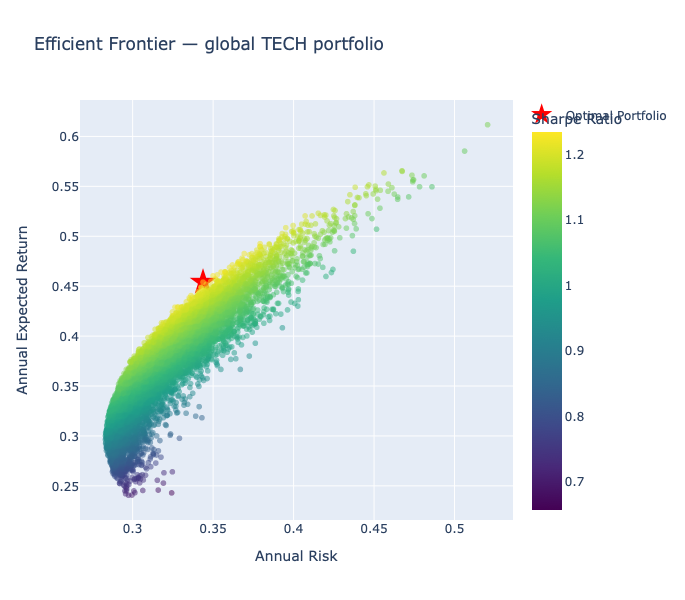

In [16]:
results_df = pd.DataFrame({
    'Return': portfolio_returns,
    'Volatility': portfolio_volatility,
    'Sharpe': portfolio_sharpe
})

for i, stock in enumerate(stocks):
    results_df[stock] = portfolio_weights[:, i]

fig = px.scatter(
    results_df,
    x='Volatility',
    y='Return',
    color='Sharpe',
    color_continuous_scale='viridis',
    title=' Efficient Frontier — global TECH portfolioallocation_df = pd.DataFrame({
    'Stock': [stock_names.get(s, s) for s in stocks],
    'Weight': best_weights
})

fig2 = px.pie(
    allocation_df,
    values='Weight',
    names='Stock',
    title='💼 Optimal Portfolio Allocation — Moroccan Stocks',
    hole=0.4
)
fig2.show()',
    labels={
        'Volatility': 'Annual Risk',
        'Return': 'Annual Expected Return',
        'Sharpe': 'Sharpe Ratio'
    },
    opacity=0.5
)


fig.add_trace(go.Scatter(
    x=[best_volatility],
    y=[best_return],
    mode='markers',
    marker=dict(size=20, color='red', symbol='star'),
    name=' Optimal Portfolio'
))

fig.update_layout(height=600)
fig.show()

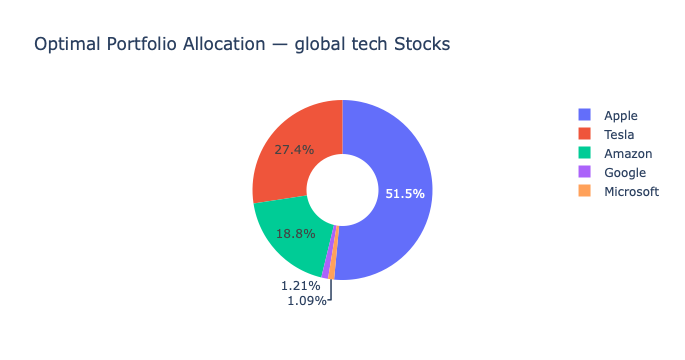

In [17]:
allocation_df = pd.DataFrame({
    'Stock': [stock_names.get(s, s) for s in stocks],
    'Weight': best_weights
})

fig2 = px.pie(
    allocation_df,
    values='Weight',
    names='Stock',
    title=' Optimal Portfolio Allocation — global tech Stocks',
    hole=0.4
)
fig2.show()

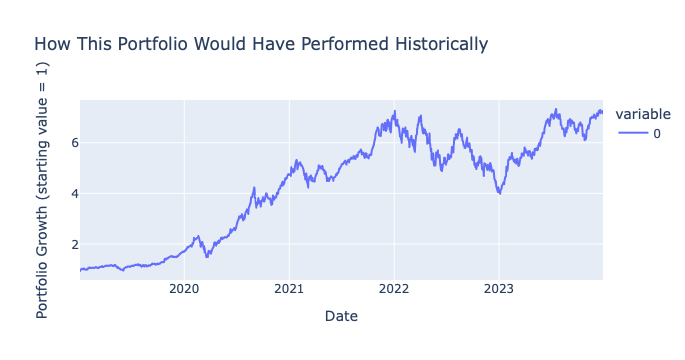

 Total return over the full period: 615.2%
 If you invested 10,000 MAD, you'd have: 71,520 MAD


In [18]:
optimal_daily_returns = (returns * best_weights).sum(axis=1)
cumulative = (1 + optimal_daily_returns).cumprod()

fig3 = px.line(
    cumulative,
    title=' How This Portfolio Would Have Performed Historically',
    labels={
        'value': 'Portfolio Growth (starting value = 1)',
        'Date': 'Date'
    }
)
fig3.show()

total = (cumulative.iloc[-1] - 1)
print(f" Total return over the full period: {total:.1%}")
print(f" If you invested 10,000 MAD, you'd have: {10000 * (1 + total):,.0f} MAD")